In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("5x127x127_training_with_morphology.csv")

In [4]:
df.head()

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.002657,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.002538,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.002606,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.005510,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.003021,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187


# EDA

In [5]:
df.columns

Index(['coord', 'dec', 'g_central_image_pop_10px_rad',
       'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad',
       'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity',
       'g_half_light_radius', 'g_isophotal_area', 'g_major_axis',
       'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad',
       'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad',
       'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad',
       'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity',
       'i_half_light_radius', 'i_isophotal_area', 'i_major_axis',
       'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad',
       'i_pos_angle', 'i_sersic_index', 'object_id',
       'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad',
       'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma',
       'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area',
       'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness',
       'r_p

In [6]:
features = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag"
    
]

df_1 = df[features +["specz_redshift"]]

In [7]:
df_1.head()

,g_cmodel_mag,r_cmodel_mag,i_cmodel_mag,z_cmodel_mag,y_cmodel_mag,specz_redshift
0,20.162785,20.303240,20.003777,19.592779,19.839014,2.17865
1,20.320715,18.924778,18.247103,17.874811,17.614677,0.43602
2,21.629736,19.881702,18.808056,18.372108,18.164425,0.56511
3,21.448307,21.582899,21.402744,20.637022,20.885055,0.84550
4,21.827169,20.187965,19.282352,18.911262,18.741877,0.51283


In [8]:
df_1.shape

(204573, 6)

In [9]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204573 entries, 0 to 204572
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   g_cmodel_mag    204573 non-null  float64
 1   r_cmodel_mag    204573 non-null  float64
 2   i_cmodel_mag    204573 non-null  float64
 3   z_cmodel_mag    204573 non-null  float64
 4   y_cmodel_mag    204573 non-null  float64
 5   specz_redshift  204573 non-null  float64
dtypes: float64(6)
memory usage: 9.4 MB


In [10]:
df_1.describe()

,g_cmodel_mag,r_cmodel_mag,i_cmodel_mag,z_cmodel_mag,y_cmodel_mag,specz_redshift
count,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000
mean,21.256327,20.246424,19.633747,19.325146,19.153789,0.595007
std,1.888613,1.880042,1.848060,1.848819,1.871167,0.572976
min,14.365486,13.768898,13.376333,13.123674,12.939251,0.010100
25%,19.719109,18.773922,18.263514,17.973379,17.789887,0.212570
50%,21.503017,20.309673,19.507687,19.136146,18.939899,0.488950
75%,22.624615,21.579090,20.993273,20.717060,20.572125,0.694360
max,29.835554,30.006908,27.931854,28.985821,33.529446,3.997880


In [11]:
df_1.duplicated().sum()

0

In [12]:
df_1['specz_redshift'].value_counts()

specz_redshift
0.63880    21
0.55790    20
0.55560    19
0.58700    18
0.70760    17
           ..
0.51197     1
0.79187     1
0.34532     1
2.37829     1
1.06695     1
Name: count, Length: 99698, dtype: int64

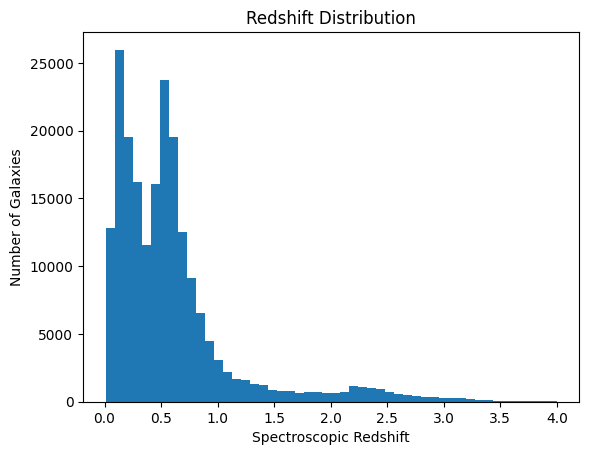

In [13]:
df_1["specz_redshift"].plot(kind="hist", bins=50)
plt.xlabel("Spectroscopic Redshift")
plt.ylabel("Number of Galaxies")
plt.title("Redshift Distribution")
plt.show()

In [14]:
def plotting(column, n):
    plt.subplot(2, 2, n)
    plt.hist(df_1[column], bins=50)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.title(column)



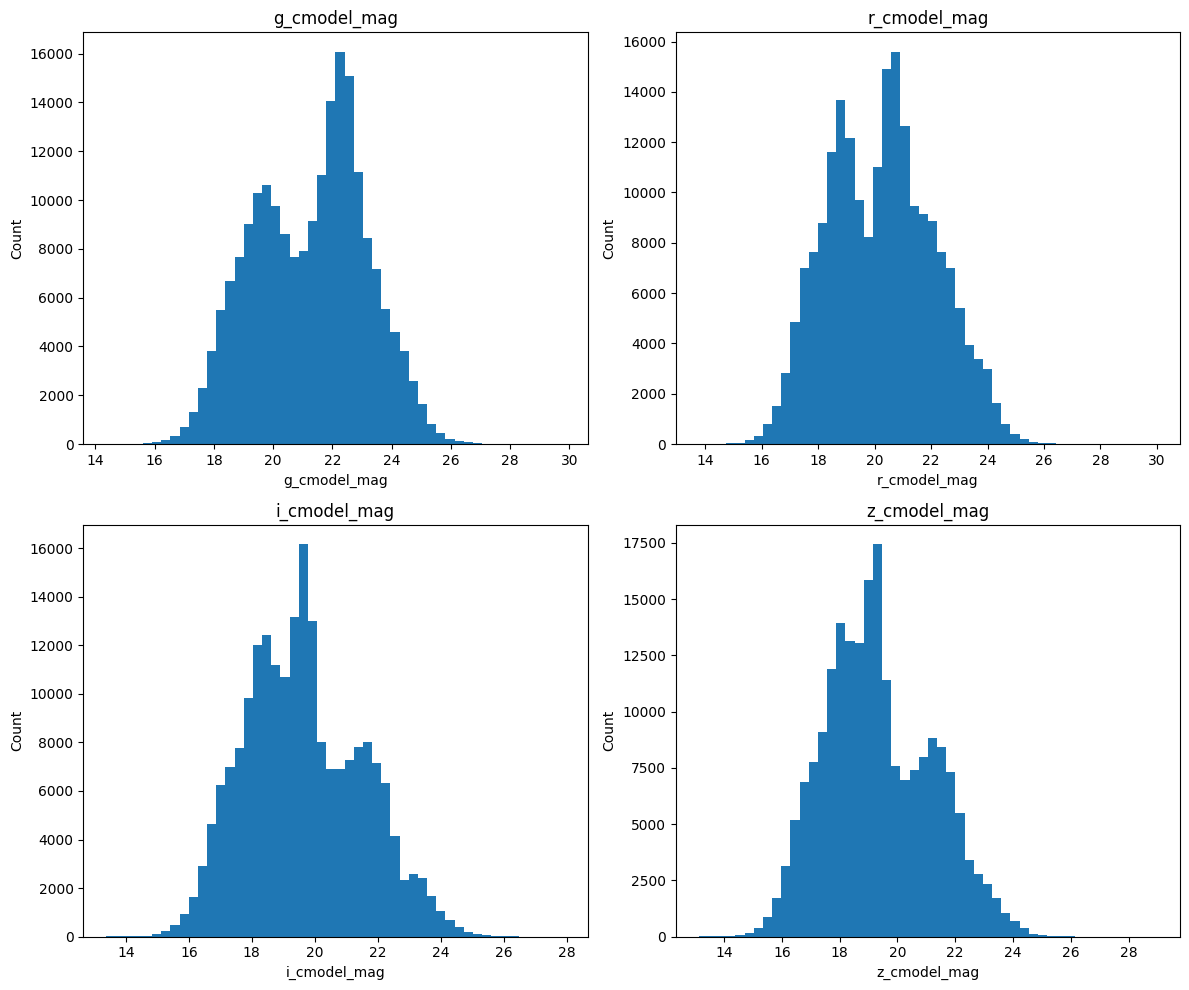

In [15]:
plt.figure(figsize=(12, 10))

plotting('g_cmodel_mag', 1)
plotting('r_cmodel_mag', 2)
plotting('i_cmodel_mag', 3)
plotting('z_cmodel_mag', 4)

plt.tight_layout()
plt.show()


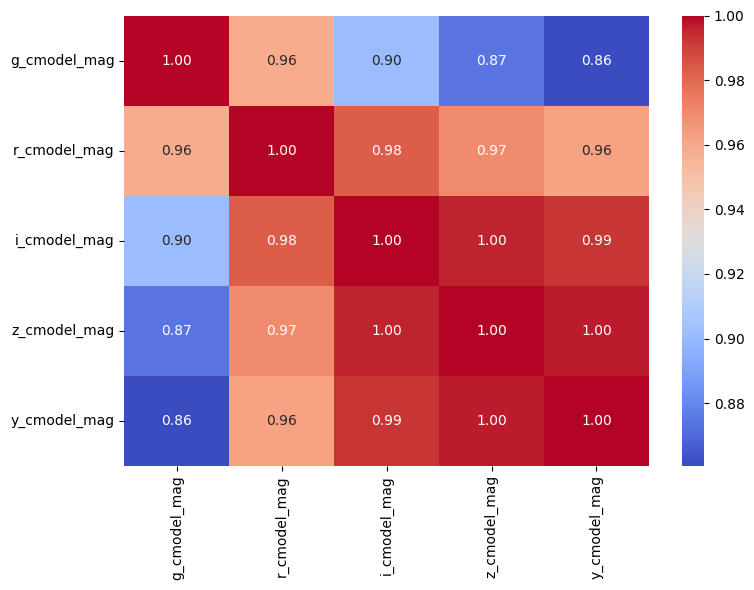

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define input features and target
X = df[features]
y = df["specz_redshift"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (163658, 5)
X_test : (40915, 5)
y_train: (163658,)
y_test : (40915,)


In [21]:
print("Training mean:", X_train_scaled.mean(axis=0))
print("Training std :", X_train_scaled.std(axis=0))

Training mean: [-7.77065214e-16 -7.35863131e-16 -3.55579624e-16  1.53776248e-15
  2.04838176e-15]
Training std : [1. 1. 1. 1. 1.]


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [23]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test_scaled)

In [25]:
print("Actual:", y_test.iloc[:10].values)
print("Predicted:", y_pred[:10])

Actual: [0.27368999 1.16630006 0.49983001 0.18476    0.62801999 1.35745203
 0.12442    0.46050999 0.89340001 0.28900001]
Predicted: [0.64488412 1.38176304 0.44378853 0.16048774 0.38489566 0.81686005
 0.21080343 0.30686672 1.01391076 1.08780815]


In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
adjusted_r2

0.34285623393533526

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.28916276712899625
MSE : 0.21456201302319128
RMSE: 0.4632083904930817
R²  : 0.34293654186979106


In [28]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R²       :", r2)
print("Adjusted R²:", adj_r2)

R²       : 0.34293654186979106
Adjusted R²: 0.34285623393533526


In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model_cv = LinearRegression()

cv_scores = cross_val_score(
    model_cv,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

CV R² scores: [0.33351522 0.34025283 0.34018354 0.3491559  0.34563212]
Mean CV R²: 0.3417479231738526
Std CV R²: 0.005337137589664733


In [30]:
accuracy_005 = (abs(y_test - y_pred) < 0.05).mean() * 100
print(f"Accuracy within ±0.05 redshift: {accuracy_005:.2f}%")

Accuracy within ±0.05 redshift: 14.32%


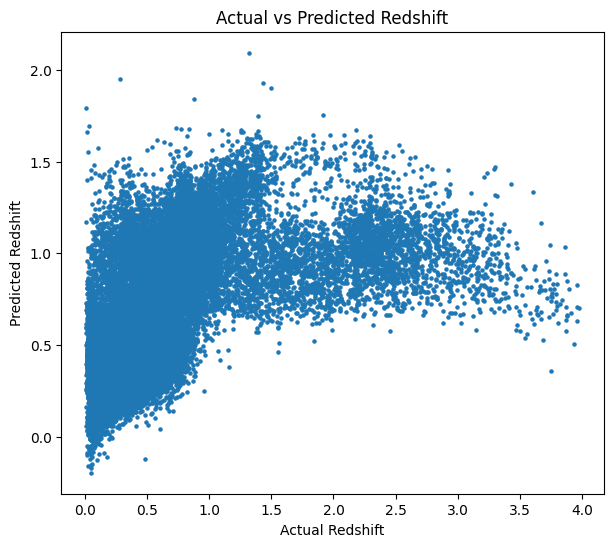

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, s=5)

plt.xlabel("Actual Redshift")
plt.ylabel("Predicted Redshift")
plt.title("Actual vs Predicted Redshift")

plt.show()

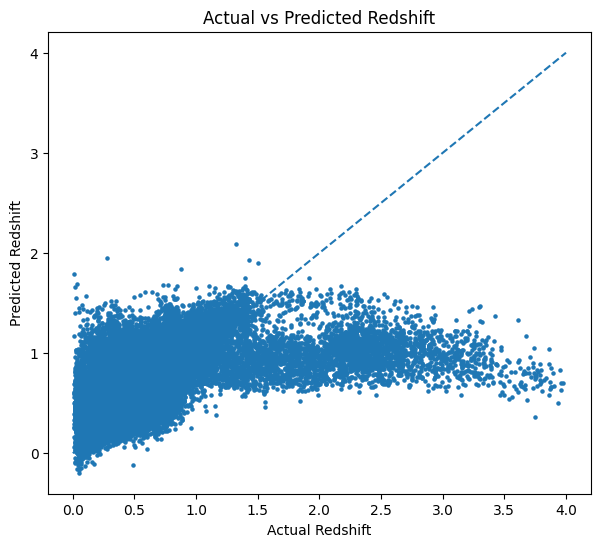

In [32]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, s=5)

# Perfect prediction line
plt.plot([0, 4], [0, 4], '--')

plt.xlabel("Actual Redshift")
plt.ylabel("Predicted Redshift")
plt.title("Actual vs Predicted Redshift")

plt.show()

# M2:Randam Forest Model

In [33]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [35]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [36]:
y_pred_rf = rf_model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest R²:", r2_rf)

Random Forest R²: 0.7309937789209129


In [42]:
from sklearn.model_selection import cross_val_score


In [43]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

CV R² scores: [0.7149259  0.72954889 0.71473424 0.71213877 0.7219878 ]
Mean CV R²: 0.7186671186030542
Std CV R²: 0.0063485989876990315


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest MSE:", mse_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 0.11853403099536813
Random Forest MSE: 0.08784313843101071
Random Forest RMSE: 0.2963834314380794


In [46]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [49]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [50]:
y_pred_rf = rf_model.predict(X_test)

In [51]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

CV R² scores: [0.71579808 0.73093042 0.71542214 0.71254187 0.72318542]
Mean CV R²: 0.7195755843755657
Std CV R²: 0.006677679851540374


In [52]:
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest R²:", r2_rf)

Random Forest R²: 0.7319381644327086


In [53]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

In [54]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)

In [55]:
y_pred_rf = rf_model.predict(X_test)

In [56]:
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest R²:", r2_rf)

Random Forest R²: 0.7318600682554559


In [57]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())


CV R² scores: [0.715188   0.72956069 0.71628052 0.71230281 0.72172485]
Mean CV R²: 0.719011375581238
Std CV R²: 0.006094778012819144


In [70]:
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest R²:", r2_rf)

Random Forest R²: 0.696373399502125


In [66]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [61]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, n_jobs=-1,
                      random_state=42)

In [62]:
y_pred_rf = rf_model.predict(X_test)

In [63]:
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest R²:", r2_rf)

Random Forest R²: 0.696373399502125


In [72]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

CV R² scores: [0.68324785 0.69459475 0.68334767 0.68107462 0.69321663]
Mean CV R²: 0.687096302748756
Std CV R²: 0.005635752703398998


In [ ]:
#current best model and now randamized search cv

In [73]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [74]:
from sklearn.model_selection import RandomizedSearchCV

In [75]:
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1],
    'max_features': [1.0, 'sqrt']
}

In [76]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [77]:
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 3.8min
[CV] END max_depth=20, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 6.0min


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [8, 10, 15, 20, None],
                                        'max_features': [1.0, 'sqrt'],
                                        'min_samples_leaf': [1],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 150, 200]},
                   random_state=42, scoring='r2', verbose=2)

In [79]:
print("Best parameters:")
print(rf_random.best_params_)

print("\nBest CV R²:")
print(rf_random.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

Best CV R²:
0.7243115165800743
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 3.4min
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 4.0min
[CV] END max_depth=8, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 2.0min
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 4.6min
[CV] END max_depth=8, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 1.3min
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 5.1min
[CV] END max_depth=8, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 2.2min
[CV] END

In [80]:
best_rf = rf_random.best_estimator_

In [81]:
y_pred_best_rf = best_rf.predict(X_test)

In [82]:
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("Tuned Random Forest Test R²:", r2_best_rf)

Tuned Random Forest Test R²: 0.734769734881845


In [83]:
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)

print("Tuned Random Forest MAE:", mae_best_rf)
print("Tuned Random Forest MSE:", mse_best_rf)
print("Tuned Random Forest RMSE:", rmse_best_rf)

Tuned Random Forest MAE: 0.12059607210881582
Tuned Random Forest MSE: 0.08661011184577035
Tuned Random Forest RMSE: 0.29429595961509625
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 5.1min
[CV] END max_depth=8, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 2.1min
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 5.0min
[CV] END max_depth=8, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 1.3min
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 3.9min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=150; total time= 2.4min
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 4.4min
[CV] END max_depth=15, max_f